In [1]:
# Установка CatBoost и LightGBM
!pip install catboost lightgbm


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, List, Optional, Callable, Any

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report
)

from catboost import CatBoostClassifier, CatBoostRegressor
import lightgbm as lgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Загрузка данных

In [3]:
base_path = Path("..")
inc_path = (base_path / "data/raw/incidents_2000.csv").resolve()
thr_path = (base_path / "data/raw/thrlist.csv").resolve()

inc = pd.read_csv(inc_path)
thr = pd.read_csv(thr_path, header=1)

df = inc.merge(
    thr,
    how="left",
    left_on="Код реализованной угрозы",
    right_on="Идентификатор УБИ"
)

In [44]:
def init_data():
    base_path = Path("..")
    inc_path = (base_path / "data/raw/incidents_2000.csv").resolve()
    thr_path = (base_path / "data/raw/thrlist.csv").resolve()

    inc = pd.read_csv(inc_path)
    thr = pd.read_csv(thr_path, header=1)

    df = inc.merge(
        thr,
        how="left",
        left_on="Код реализованной угрозы",
        right_on="Идентификатор УБИ"
    )

    return df

# Приведение типов

In [4]:
def change_dtype_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    date_cols = [
        "Региональное время",
        "Дата инцидента",
        "Дата включения угрозы в БнД УБИ",
        "Дата последнего изменения данных"
    ]
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

    num_cols = [
        "Количество хостов",
        "Успех",
        "Код реализованной угрозы",
        "Код предприятия",
        "Идентификатор УБИ"
    ]
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

df = change_dtype_dataframe(df)

# Базовая очистка

In [5]:
def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.sort_values('Региональное время', ascending=False).drop_duplicates(subset=['Код предприятия'], keep='first')
    
    if "Статус угрозы" in df.columns:
        df = df[df["Статус угрозы"] != "Архивная"]

    if "Источник угрозы (характеристика и потенциал нарушителя)" in df.columns:
        mode_val = df["Источник угрозы (характеристика и потенциал нарушителя)"].mode()
        if len(mode_val) > 0:
            df["Источник угрозы (характеристика и потенциал нарушителя)"] = (
                df["Источник угрозы (характеристика и потенциал нарушителя)"].fillna(mode_val.iloc[0])
            )

    return df.reset_index(drop=True)

df = basic_cleaning(df)
df.shape

(1770, 20)

# Feature engineering

In [6]:
def enrich_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "Региональное время" in df.columns:
        df["Час_инцидента"] = df["Региональное время"].dt.hour
        df["День_недели"] = df["Региональное время"].dt.dayofweek
        df["Месяц"] = df["Региональное время"].dt.month
        df["Квартал"] = df["Региональное время"].dt.quarter
        df["Год"] = df["Региональное время"].dt.year
        df["День_месяца"] = df["Региональное время"].dt.day
        df["Выходной"] = df["День_недели"].isin([5, 6]).astype(int)

        season_map = {
            12: 0, 1: 0, 2: 0,   # зима
            3: 1, 4: 1, 5: 1,    # весна
            6: 2, 7: 2, 8: 2,    # лето
            9: 3, 10: 3, 11: 3   # осень
        }
        df["Сезон"] = df["Месяц"].map(season_map)

        # циклические признаки для часа
        df["Час_sin"] = np.sin(2 * np.pi * df["Час_инцидента"] / 24)
        df["Час_cos"] = np.cos(2 * np.pi * df["Час_инцидента"] / 24)

        # циклические признаки для дня недели
        df["ДеньНед_sin"] = np.sin(2 * np.pi * df["День_недели"] / 7)
        df["ДеньНед_cos"] = np.cos(2 * np.pi * df["День_недели"] / 7)

    if "Дата включения угрозы в БнД УБИ" in df.columns:
        df["Год_включения_угрозы"] = df["Дата включения угрозы в БнД УБИ"].dt.year
        df["Месяц_включения_угрозы"] = df["Дата включения угрозы в БнД УБИ"].dt.month

    if {"Дата последнего изменения данных", "Дата включения угрозы в БнД УБИ"}.issubset(df.columns):
        df["Дней_в_базе"] = (
            df["Дата последнего изменения данных"] - df["Дата включения угрозы в БнД УБИ"]
        ).dt.days

    if {"Дата инцидента", "Дата включения угрозы в БнД УБИ"}.issubset(df.columns):
        df["Дней_с_включения_угрозы"] = (
            df["Дата инцидента"] - df["Дата включения угрозы в БнД УБИ"]
        ).dt.days

    if "Количество хостов" in df.columns:
        df["Размер инфраструктуры"] = pd.cut(
            df["Количество хостов"],
            bins=[-np.inf, 250, 1000, 2000, np.inf],
            labels=["Малая", "Средняя", "Крупная", "Очень крупная"]
        )

    return df

df = enrich_dataframe(df)

# Наборы признаков

In [7]:
#BASELINE

ALL_FEATURES_EXCLUDE = [
    "Успех",
    "Код реализованной угрозы",
    "Объект воздействия",
    "Региональное время",
    "Дата инцидента"
]

base_features = [
    "Количество хостов",
    "Источник угрозы (характеристика и потенциал нарушителя)",
    "Размер инфраструктуры",
    "Дней_в_базе",
    "Год_включения_угрозы",
    "Месяц_включения_угрозы"
]

time_features = [
    "Час_sin", "Час_cos",
    "ДеньНед_sin", "ДеньНед_cos",
    "Месяц", "Квартал", "Выходной"
]

extended_features = list(set(base_features + time_features + [
    "Дней_с_включения_угрозы",
    "Год"
]))

FEATURE_SETS = {
    "base": base_features,
    "time": time_features,
    "extended": extended_features
}

# Подготовка данных под задачу

In [8]:
def prepare_task_data(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: List[str],
    time_col: str = "Региональное время",
    filter_fn: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None
):
    data = df.copy()

    if filter_fn is not None:
        data = filter_fn(data)

    data = data.dropna(subset=[time_col, target_col]).copy()
    data = data.sort_values(time_col).reset_index(drop=True)

    valid_features = [col for col in feature_cols if col in data.columns]
    X = data[valid_features].copy()
    y = data[target_col].copy()
    timestamps = data[time_col].copy()

    return data, X, y, timestamps

# Препроцессор

def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

    return preprocessor

In [69]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin

class MultiLabelSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, sep=';'):
        self.sep = sep
    def fit(self, X, y=None): return self
    def transform(self, X):
        col = X if isinstance(X, pd.Series) else pd.Series(X)
        return col.str.split(self.sep).apply(
            lambda x: [i.strip() for i in x if i.strip()]
        ).tolist()

def build_preprocessor(X: pd.DataFrame, cat_cols, num_cols, text_cols) -> ColumnTransformer:

    
    
    # 3. Трансформеры
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])

    # 4. Сборка ColumnTransformer
    transformers = []
    if num_cols:
        transformers.append(("num", num_pipe, num_cols))
    if cat_cols:
        transformers.append(("cat", cat_pipe, cat_cols))
    if text_cols:
        # TF-IDF ожидает 1D массив. Берём первую найденную текстовую колонку.
        transformers.append(("text", TfidfVectorizer(max_features=500, ngram_range=(1,2), sublinear_tf=True), text_cols[0]))
    for col in text_cols:
        transformers.append((f"mlb_{col}", Pipeline([
            ("split", MultiLabelSplitter()),
            ("bin", MultiLabelBinarizer())
        ]), col))

    # sparse_threshold=0.3 предотвращает случайную конвертацию всей матрицы в dense
    return ColumnTransformer(transformers, remainder='drop', sparse_threshold=0.3)

# Holdout по времени

In [10]:
def time_holdout_split(X, y, timestamps, test_size=0.2):
    n = len(X)
    split_idx = int(n * (1 - test_size))

    X_train = X.iloc[:split_idx].copy()
    X_test = X.iloc[split_idx:].copy()

    y_train = y.iloc[:split_idx].copy()
    y_test = y.iloc[split_idx:].copy()

    ts_train = timestamps.iloc[:split_idx].copy()
    ts_test = timestamps.iloc[split_idx:].copy()

    return X_train, X_test, y_train, y_test, ts_train, ts_test

# Circular MAE

циркулярные (круговые) метрики ошибок для прогнозирования циклических величин. Это особенно важно для признаков, где значения "замыкаются сами на себя" (например, часы суток, дни недели, углы).

In [11]:
def circular_abs_error(y_true, y_pred, period=24):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    diff = np.abs(y_true - y_pred)
    circ_diff = np.minimum(diff, period - diff)
    return circ_diff

def circular_mae(y_true, y_pred, period=24):
    return circular_abs_error(y_true, y_pred, period=period).mean()

def circular_rmse(y_true, y_pred, period=24):
    err = circular_abs_error(y_true, y_pred, period=period)
    return np.sqrt(np.mean(err ** 2))

# Метрики классификации

In [12]:
def compute_binary_metrics(y_true, y_pred, y_proba=None) -> Dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    if y_proba is not None:
        if y_proba.ndim == 2 and y_proba.shape[1] >= 2:
            metrics["roc_auc"] = roc_auc_score(y_true, y_proba[:, 1])
            metrics["log_loss"] = log_loss(y_true, y_proba)
        else:
            metrics["roc_auc"] = np.nan
            metrics["log_loss"] = np.nan

    return metrics


def compute_multiclass_metrics(y_true, y_pred, y_proba=None) -> Dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

    if y_proba is not None:
        try:
            metrics["log_loss"] = log_loss(y_true, y_proba)
        except:
            metrics["log_loss"] = np.nan

    return metrics

# Метрики регрессии

In [13]:
def compute_regression_metrics(y_true, y_pred) -> Dict[str, float]:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }

def compute_circular_regression_metrics(y_true, y_pred, period=24) -> Dict[str, float]:
    return {
        "circular_mae": circular_mae(y_true, y_pred, period=period),
        "circular_rmse": circular_rmse(y_true, y_pred, period=period),
        "mae": mean_absolute_error(y_true, y_pred)
    }

# Временная кросс-валидация

In [14]:
def evaluate_time_series_cv(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    model,
    task_type: str,
    n_splits: int = 5,
    period: int = 24,
    cat_cols, 
    num_cols, 
    text_cols
) -> pd.DataFrame:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        preprocessor = build_preprocessor(X_tr, cat_cols, num_cols, text_cols)
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", clone(model))
        ])

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)

        row = {"fold": fold}

        if task_type == "binary":
            y_proba = pipe.predict_proba(X_val) if hasattr(pipe, "predict_proba") else None
            row.update(compute_binary_metrics(y_val, y_pred, y_proba))

        elif task_type == "multiclass":
            y_proba = pipe.predict_proba(X_val) if hasattr(pipe, "predict_proba") else None
            row.update(compute_multiclass_metrics(y_val, y_pred, y_proba))

        elif task_type == "regression":
            row.update(compute_regression_metrics(y_val, y_pred))

        elif task_type == "circular_regression":
            row.update(compute_circular_regression_metrics(y_val, y_pred, period=period))

        fold_results.append(row)

    return pd.DataFrame(fold_results)

# Универсальная функция обучения одной задачи

In [15]:
def run_experiment(
    df: pd.DataFrame,
    task_name: str,
    task_type: str,
    target_col: str,
    feature_cols: List[str],
    model,
    time_col: str = "Региональное время",
    filter_fn: Optional[Callable[[pd.DataFrame], pd.DataFrame]] = None,
    test_size: float = 0.2,
    n_splits: int = 5,
    period: int = 24
    cat_cols, 
    num_cols, 
    text_cols
) -> Dict[str, Any]:

    data, X, y, timestamps = prepare_task_data(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols,
        time_col=time_col,
        filter_fn=filter_fn
    )

    X_train, X_test, y_train, y_test, ts_train, ts_test = time_holdout_split(
        X, y, timestamps, test_size=test_size
    )

    cv_results = evaluate_time_series_cv(
        X_train=X_train,
        y_train=y_train,
        model=model,
        task_type=task_type,
        n_splits=n_splits,
        period=period
        cat_cols=cat_cols, 
        num_cols=num_cols, 
        text_cols=ext_cols
    )

    preprocessor = build_preprocessor(X_train, cat_cols, num_cols, text_cols)
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", clone(model))
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    if task_type == "binary":
        y_proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
        test_metrics = compute_binary_metrics(y_test, y_pred, y_proba)

    elif task_type == "multiclass":
        y_proba = pipe.predict_proba(X_test) if hasattr(pipe, "predict_proba") else None
        test_metrics = compute_multiclass_metrics(y_test, y_pred, y_proba)

    elif task_type == "regression":
        y_proba = None
        test_metrics = compute_regression_metrics(y_test, y_pred)

    elif task_type == "circular_regression":
        y_proba = None
        test_metrics = compute_circular_regression_metrics(y_test, y_pred, period=period)

    result = {
        "task_name": task_name,
        "task_type": task_type,
        "target_col": target_col,
        "feature_cols": feature_cols,
        "n_rows": len(data),
        "train_size": len(X_train),
        "test_size": len(X_test),
        "cv_results": cv_results,
        "cv_mean": cv_results.drop(columns=["fold"]).mean(numeric_only=True).to_dict(),
        "cv_std": cv_results.drop(columns=["fold"]).std(numeric_only=True).to_dict(),
        "test_metrics": test_metrics,
        "pipeline": pipe,
        "X_test": X_test,
        "y_test": y_test,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "timestamps_test": ts_test
    }

    return result

# Описание задач
Теперь формализуем все 4 модели.

In [16]:
TASKS = {
    "model_1_success": {
        "task_name": "Успешность атаки",
        "task_type": "binary",
        "target_col": "Успех",
        "filter_fn": None,
        "period": None
    },
    "model_2_hour": {
        "task_name": "Час наступления атаки",
        "task_type": "circular_regression",
        "target_col": "Час_инцидента",
        "filter_fn": lambda x: x[x["Успех"] == 1],
        "period": 24
    },
    "model_2_weekday": {
        "task_name": "День недели атаки",
        "task_type": "multiclass",
        "target_col": "День_недели",
        "filter_fn": lambda x: x[x["Успех"] == 1],
        "period": None
    },
    "model_2_season": {
        "task_name": "Сезон атаки",
        "task_type": "multiclass",
        "target_col": "Сезон",
        "filter_fn": lambda x: x[x["Успех"] == 1],
        "period": None
    },
    "model_3_threat_type": {
        "task_name": "Тип угрозы",
        "task_type": "multiclass",
        "target_col": "Код реализованной угрозы",
        "filter_fn": None,
        "period": None
    },
    "model_4_target_object": {
        "task_name": "Объект воздействия",
        "task_type": "multiclass",
        "target_col": "Объект воздействия",
        "filter_fn": None,
        "period": None
    }
}

# Базовые модели

In [17]:
MODELS = {
    "binary_rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "multiclass_rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "hour_rf": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
        # ========== CATBOOST ==========
    "binary_catboost": CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        l2_leaf_reg=3,
        border_count=128,
        random_seed=42,
        verbose=0,
        thread_count=-1,
        auto_class_weights='Balanced',
        early_stopping_rounds=50
    ),
    
    "multiclass_catboost": CatBoostClassifier(
        iterations=500,
        depth=8,
        learning_rate=0.03,
        l2_leaf_reg=3,
        border_count=128,
        random_seed=42,
        verbose=0,
        thread_count=-1,
        auto_class_weights='Balanced',
        early_stopping_rounds=50,
        loss_function='MultiClass'
    ),
    
    "hour_catboost": CatBoostRegressor(
        iterations=500,
        depth=8,
        learning_rate=0.03,
        l2_leaf_reg=3,
        border_count=128,
        random_seed=42,
        verbose=0,
        thread_count=-1,
        early_stopping_rounds=50
    ),
    
    # ========== LIGHTGBM ==========
    "binary_lgbm": lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=-1
    ),
    
    "multiclass_lgbm": lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=10,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
        verbose=-1
    ),
    
    "hour_lgbm": lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=10,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

In [18]:
result_m1 = run_experiment(
    df=df,
    task_name=TASKS["model_1_success"]["task_name"],
    task_type=TASKS["model_1_success"]["task_type"],
    target_col=TASKS["model_1_success"]["target_col"],
    feature_cols=FEATURE_SETS["extended"],
    model=MODELS["binary_rf"],
    time_col="Региональное время",
    filter_fn=TASKS["model_1_success"]["filter_fn"],
    test_size=0.2,
    n_splits=5
)

result_m1["test_metrics"]

{'accuracy': 0.5084745762711864,
 'balanced_accuracy': 0.5148467432950191,
 'precision': 0.5,
 'recall': 0.8908045977011494,
 'f1': 0.640495867768595,
 'roc_auc': 0.5047254150702426,
 'log_loss': 0.7139808836599546}

In [19]:
result_m2_hour = run_experiment(
    df=df,
    task_name=TASKS["model_2_hour"]["task_name"],
    task_type=TASKS["model_2_hour"]["task_type"],
    target_col=TASKS["model_2_hour"]["target_col"],
    feature_cols=FEATURE_SETS["extended"],
    model=MODELS["hour_rf"],
    time_col="Региональное время",
    filter_fn=TASKS["model_2_hour"]["filter_fn"],
    test_size=0.2,
    n_splits=5,
    period=24
)

result_m2_hour["test_metrics"]

{'circular_mae': np.float64(0.0), 'circular_rmse': np.float64(0.0), 'mae': 0.0}

In [20]:
result_m3 = run_experiment(
    df=df,
    task_name=TASKS["model_3_threat_type"]["task_name"],
    task_type=TASKS["model_3_threat_type"]["task_type"],
    target_col=TASKS["model_3_threat_type"]["target_col"],
    feature_cols=FEATURE_SETS["extended"],
    model=MODELS["multiclass_rf"],
    time_col="Региональное время",
    filter_fn=TASKS["model_3_threat_type"]["filter_fn"],
    test_size=0.2,
    n_splits=5
)

result_m3["test_metrics"]

{'accuracy': 0.2796610169491525,
 'balanced_accuracy': 0.2760828625235405,
 'f1_macro': 0.22692683414332898,
 'f1_weighted': 0.26000533260420267,
 'precision_macro': 0.23094074671282203,
 'recall_macro': 0.25189003436426116,
 'log_loss': nan}

In [21]:
result_m4 = run_experiment(
    df=df,
    task_name=TASKS["model_4_target_object"]["task_name"],
    task_type=TASKS["model_4_target_object"]["task_type"],
    target_col=TASKS["model_4_target_object"]["target_col"],
    feature_cols=FEATURE_SETS["extended"],
    model=MODELS["multiclass_rf"],
    time_col="Региональное время",
    filter_fn=TASKS["model_4_target_object"]["filter_fn"],
    test_size=0.2,
    n_splits=5
)

result_m4["test_metrics"]

{'accuracy': 0.2514124293785311,
 'balanced_accuracy': 0.3059800235883827,
 'f1_macro': 0.23450234335695938,
 'f1_weighted': 0.2382396834671589,
 'precision_macro': 0.2589676556166431,
 'recall_macro': 0.28591575974652156,
 'log_loss': nan}

# Универсальный запуск серии экспериментов

In [22]:
'''def select_model_by_task(task_type: str, model_type: str = "catboost"):
    if task_type == "binary":
        return MODELS["binary_rf"]
    elif task_type == "multiclass":
        return MODELS["multiclass_rf"]
    elif task_type == "circular_regression":
        return MODELS["hour_rf"]
    elif task_type == "regression":
        return MODELS["hour_rf"]
    else:
        raise ValueError(f"Unknown task_type: {task_type}")'''
        
def select_model_by_task(task_type: str, model_name: str = None):
    """
    Выбор модели для заданного типа задачи.
    
    Parameters:
    -----------
    task_type : str
        Тип задачи: 'binary', 'multiclass', 'circular_regression', 'regression'
    model_name : str, optional
        Имя модели. Если None, используется дефолтная (catboost).
        Варианты: 'catboost', 'lgbm', 'nn', 'rf', 'all'
    
    Returns:
    --------
    model or dict : estimator or dict of estimators
        Если model_name='all', возвращает словарь всех подходящих моделей
    """
    # Определяем суффикс для модели
    if task_type == "binary":
        suffix = "binary"
    elif task_type == "multiclass":
        suffix = "multiclass"
    elif task_type in ["circular_regression", "regression"]:
        suffix = "hour"
    else:
        raise ValueError(f"Unknown task_type: {task_type}")
    
    # Доступные модели для данного типа задачи
    available_models = {
        "catboost": MODELS.get(f"{suffix}_catboost"),
        "lgbm": MODELS.get(f"{suffix}_lgbm"),
        "rf": MODELS.get(f"{suffix}_rf")
    }
    
    # Удаляем None значения
    available_models = {k: v for k, v in available_models.items() if v is not None}
    
    if not available_models:
        raise ValueError(f"No models available for task_type: {task_type}")
    
    # Если запрошены все модели
    if model_name == "all":
        return available_models
    
    # Если имя модели не указано, берем первую (catboost)
    if model_name is None:
        model_name = "catboost" if "catboost" in available_models else list(available_models.keys())[0]
    
    if model_name not in available_models:
        raise ValueError(
            f"Model '{model_name}' not available for {task_type}. "
            f"Available: {list(available_models.keys())}"
        )
    
    return available_models[model_name]
    
 """   
def run_feature_set_benchmark(
    df: pd.DataFrame,
    tasks: Dict[str, Dict],
    feature_sets: Dict[str, List[str]],
    time_col: str = "Региональное время",
    test_size: float = 0.2,
    n_splits: int = 5,
    model_name : str = 'rf'
) -> Dict[str, Dict]:

    all_results = {}

    for task_key, task_cfg in tasks.items():
        all_results[task_key] = {}

        for fs_name, fs_cols in feature_sets.items():
            print(f"\n===== {task_key} | feature_set={fs_name} =====")

            model = select_model_by_task(task_cfg["task_type"], model_name = model_name)

            result = run_experiment(
                df=df,
                task_name=task_cfg["task_name"],
                task_type=task_cfg["task_type"],
                target_col=task_cfg["target_col"],
                feature_cols=fs_cols,
                model=model,
                time_col=time_col,
                filter_fn=task_cfg["filter_fn"],
                test_size=test_size,
                n_splits=n_splits,
                period=task_cfg.get("period", 24) if task_cfg.get("period") else 24
            )

            all_results[task_key][fs_name] = result

    return all_results"""

# Сводная таблица результатов

In [23]:
def results_to_dataframe(all_results: Dict[str, Dict]) -> pd.DataFrame:
    rows = []

    for task_key, task_runs in all_results.items():
        for fs_name, res in task_runs.items():
            row = {
                "task_key": task_key,
                "task_name": res["task_name"],
                "task_type": res["task_type"],
                "feature_set": fs_name,
                "n_rows": res["n_rows"],
                "train_size": res["train_size"],
                "test_size": res["test_size"]
            }

            for k, v in res["test_metrics"].items():
                row[f"test_{k}"] = v

            for k, v in res["cv_mean"].items():
                row[f"cv_mean_{k}"] = v

            rows.append(row)

    return pd.DataFrame(rows)

# Визуализация результатов

In [24]:
def show_cv_results(result: Dict[str, Any]):
    display(result["cv_results"])
    print("CV mean:", result["cv_mean"])
    print("CV std:", result["cv_std"])
    print("Test metrics:", result["test_metrics"])

In [25]:
def plot_confusion(result: Dict[str, Any], labels=None):
    if result["task_type"] not in ["binary", "multiclass"]:
        print("Confusion matrix only for classification tasks.")
        return

    cm = confusion_matrix(result["y_test"], result["y_pred"])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, cmap="Blues", annot=False)
    plt.title(result["task_name"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [26]:
def plot_regression_predictions(result: Dict[str, Any]):
    if result["task_type"] not in ["regression", "circular_regression"]:
        print("Only for regression tasks.")
        return

    temp = pd.DataFrame({
        "timestamp": result["timestamps_test"].values,
        "y_true": result["y_test"].values,
        "y_pred": result["y_pred"]
    })

    plt.figure(figsize=(14, 5))
    plt.plot(temp["timestamp"], temp["y_true"], label="True", alpha=0.8)
    plt.plot(temp["timestamp"], temp["y_pred"], label="Pred", alpha=0.8)
    plt.legend()
    plt.title(result["task_name"])
    plt.show()

# Универсальный time-aware подбор гиперпараметров

In [27]:
from itertools import product

def manual_time_series_search(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    base_model,
    param_grid: Dict[str, List[Any]],
    task_type: str,
    n_splits: int = 5,
    period: int = 24,
    optimize_metric: str = None
) -> pd.DataFrame:

    keys = list(param_grid.keys())
    values = list(param_grid.values())
    combos = list(product(*values))

    rows = []

    for combo in combos:
        params = dict(zip(keys, combo))
        model = clone(base_model).set_params(**params)

        cv_res = evaluate_time_series_cv(
            X_train=X_train,
            y_train=y_train,
            model=model,
            task_type=task_type,
            n_splits=n_splits,
            period=period
        )

        mean_scores = cv_res.drop(columns=["fold"]).mean(numeric_only=True).to_dict()
        row = params.copy()
        row.update({f"cv_{k}": v for k, v in mean_scores.items()})
        rows.append(row)

    result_df = pd.DataFrame(rows)

    if optimize_metric is not None and optimize_metric in result_df.columns:
        ascending = optimize_metric in ["cv_log_loss", "cv_mae", "cv_rmse", "cv_circular_mae", "cv_circular_rmse"]
        result_df = result_df.sort_values(optimize_metric, ascending=ascending)

    return result_df

# Запуск


model_1_success: Успешность атаки


,fold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,log_loss
0,1,0.521186,0.517535,0.526316,0.661157,0.586081,0.501114,0.858759
1,2,0.491525,0.500324,0.530120,0.352000,0.423077,0.506162,0.864602
2,3,0.495763,0.513348,0.561404,0.253968,0.349727,0.477056,0.879224
3,4,0.495763,0.488150,0.431373,0.419048,0.425121,0.452635,0.867223
4,5,0.487288,0.501371,0.536232,0.293651,0.379487,0.460245,0.842792


CV mean: {'accuracy': 0.49830508474576274, 'balanced_accuracy': 0.5041455473802092, 'precision': 0.5170888426501807, 'recall': 0.395964738292011, 'f1': 0.43269844750956654, 'roc_auc': 0.47944261212557987, 'log_loss': 0.8625199255271181}
CV std: {'accuracy': 0.013264810036015725, 'balanced_accuracy': 0.01164178801463363, 'precision': 0.049830936253316784, 'recall': 0.16079786320505346, 'f1': 0.09136713391819536, 'roc_auc': 0.023856008981497204, 'log_loss': 0.013311831463016772}
Test metrics: {'accuracy': 0.5112994350282486, 'balanced_accuracy': 0.5149425287356322, 'precision': 0.5019762845849802, 'recall': 0.7298850574712644, 'f1': 0.594847775175644, 'roc_auc': 0.520242656449553, 'log_loss': 0.8031308254484025}


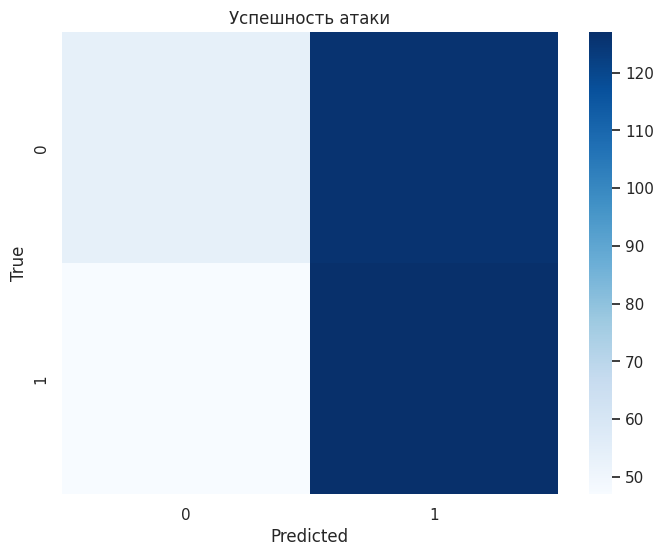


model_2_hour: Час наступления атаки


,fold,circular_mae,circular_rmse,mae
0,1,0.757233,0.998750,0.757233
1,2,0.222661,0.317801,0.222661
2,3,0.123500,0.173024,0.123500
3,4,0.162729,0.226581,0.162729
4,5,0.186652,0.274875,0.186652


CV mean: {'circular_mae': 0.2905550742338733, 'circular_rmse': 0.3982062395414486, 'mae': 0.2905550742338733}
CV std: {'circular_mae': 0.26336336472804556, 'circular_rmse': 0.34003336501459214, 'mae': 0.26336336472804556}
Test metrics: {'circular_mae': np.float64(0.1920583958522433), 'circular_rmse': np.float64(0.3012697146133992), 'mae': 0.1920583958522433}


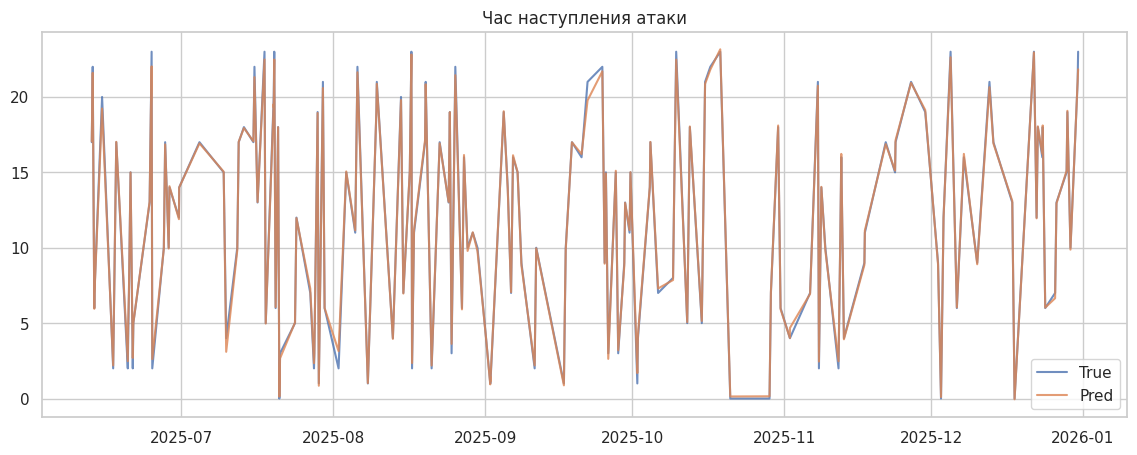


model_2_weekday: День недели атаки


,fold,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
0,1,1.0,1.0,1.0,1.0,1.0,1.0,0.008843
1,2,1.0,1.0,1.0,1.0,1.0,1.0,0.003747
2,3,1.0,1.0,1.0,1.0,1.0,1.0,0.002386
3,4,1.0,1.0,1.0,1.0,1.0,1.0,0.001779
4,5,1.0,1.0,1.0,1.0,1.0,1.0,0.001470


CV mean: {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'f1_macro': 1.0, 'f1_weighted': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'log_loss': 0.0036450057994975664}
CV std: {'accuracy': 0.0, 'balanced_accuracy': 0.0, 'f1_macro': 0.0, 'f1_weighted': 0.0, 'precision_macro': 0.0, 'recall_macro': 0.0, 'log_loss': 0.003034286231756322}
Test metrics: {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'f1_macro': 1.0, 'f1_weighted': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'log_loss': 0.0011972012064865281}


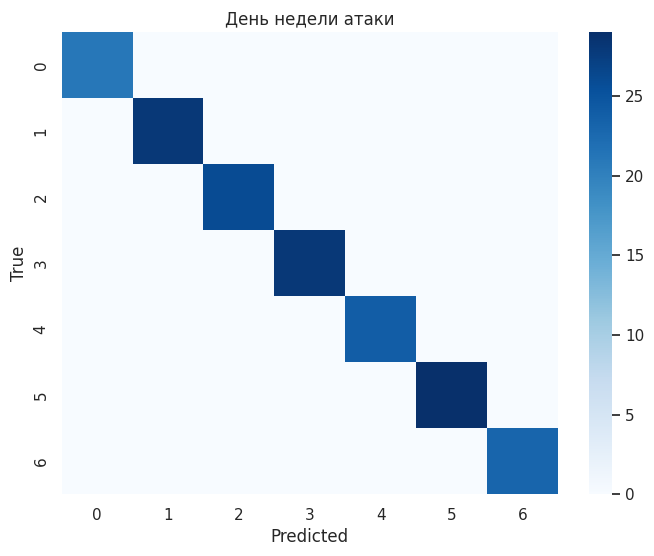


model_2_season: Сезон атаки


,fold,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
0,1,0.415254,0.500000,0.293413,0.243682,0.207627,0.500000,NaN
1,2,0.754237,0.880658,0.737776,0.797317,0.758333,0.880658,NaN
2,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
3,4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
4,5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN


CV mean: {'accuracy': 0.8338983050847457, 'balanced_accuracy': 0.8761316872427983, 'f1_macro': 0.8062377971463824, 'f1_weighted': 0.8081998896980362, 'precision_macro': 0.7931920903954802, 'recall_macro': 0.8761316872427983, 'log_loss': nan}
CV std: {'accuracy': 0.257088531581937, 'balanced_accuracy': 0.21652113887580945, 'f1_macro': 0.3083453873600344, 'f1_weighted': 0.3275517445106924, 'precision_macro': 0.34366044415640995, 'recall_macro': 0.21652113887580945, 'log_loss': nan}
Test metrics: {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'f1_macro': 1.0, 'f1_weighted': 1.0, 'precision_macro': 1.0, 'recall_macro': 1.0, 'log_loss': nan}


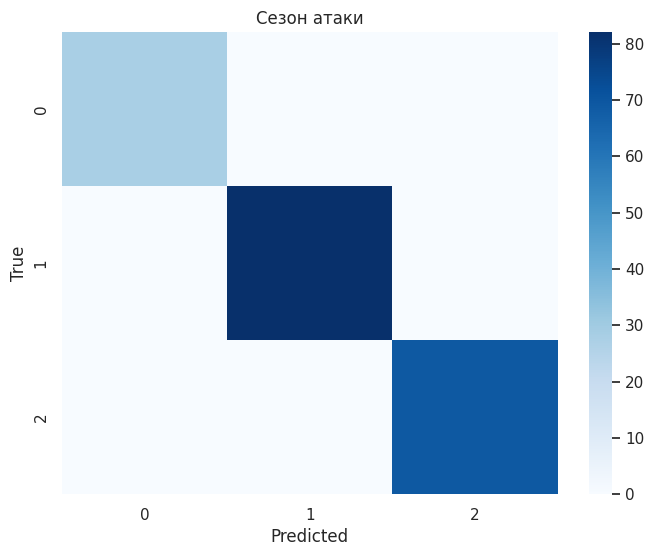


model_3_threat_type: Тип угрозы


,fold,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
0,1,0.084746,0.065972,0.050531,0.083208,0.055652,0.057927,NaN
1,2,0.156780,0.186207,0.130071,0.140137,0.129822,0.156977,NaN
2,3,0.207627,0.183453,0.140927,0.197464,0.142630,0.157407,NaN
3,4,0.233051,0.234694,0.173741,0.217393,0.172571,0.197143,NaN
4,5,0.292373,0.267117,0.209984,0.280475,0.213254,0.228516,NaN


CV mean: {'accuracy': 0.19491525423728812, 'balanced_accuracy': 0.18748867017043117, 'f1_macro': 0.14105091995981273, 'f1_weighted': 0.1837354437896046, 'precision_macro': 0.14278587911584037, 'recall_macro': 0.1595940431307859, 'log_loss': nan}
CV std: {'accuracy': 0.07858998724996359, 'balanced_accuracy': 0.0764087625048796, 'f1_macro': 0.05944502033166476, 'f1_weighted': 0.07531015939521088, 'precision_macro': 0.0583378310028167, 'recall_macro': 0.06424183923525507, 'log_loss': nan}
Test metrics: {'accuracy': 0.268361581920904, 'balanced_accuracy': 0.25508474576271184, 'f1_macro': 0.22364148197481531, 'f1_weighted': 0.2687482323075543, 'precision_macro': 0.23585858585858585, 'recall_macro': 0.22803030303030303, 'log_loss': nan}


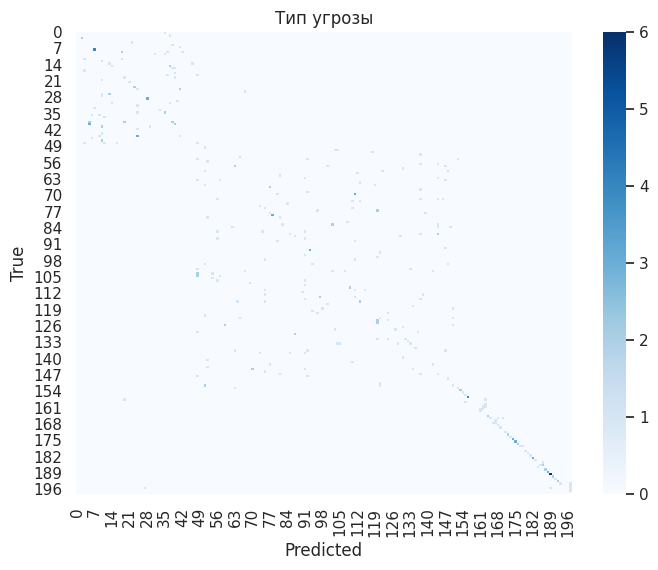


model_4_target_object: Объект воздействия


,fold,accuracy,balanced_accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,log_loss
0,1,0.118644,0.093780,0.071417,0.107974,0.073274,0.083550,NaN
1,2,0.161017,0.182806,0.131242,0.149233,0.135876,0.152338,NaN
2,3,0.211864,0.186474,0.146397,0.205344,0.155922,0.160575,NaN
3,4,0.241525,0.237869,0.177765,0.219186,0.176139,0.210979,NaN
4,5,0.343220,0.298857,0.224622,0.333036,0.231971,0.251538,NaN


CV mean: {'accuracy': 0.21525423728813556, 'balanced_accuracy': 0.19995708732090972, 'f1_macro': 0.15028876058862095, 'f1_weighted': 0.2029545980182089, 'precision_macro': 0.15463638632197943, 'recall_macro': 0.17179592030274043, 'log_loss': nan}
CV std: {'accuracy': 0.08566241539373476, 'balanced_accuracy': 0.07577583495048199, 'f1_macro': 0.05674286240906612, 'f1_weighted': 0.08529019571118972, 'precision_macro': 0.05791460155576226, 'recall_macro': 0.06361212365893516, 'log_loss': nan}
Test metrics: {'accuracy': 0.2768361581920904, 'balanced_accuracy': 0.25816317755172247, 'f1_macro': 0.220980202020202, 'f1_weighted': 0.27355341143476736, 'precision_macro': 0.2316798663324979, 'recall_macro': 0.23544481792717087, 'log_loss': nan}


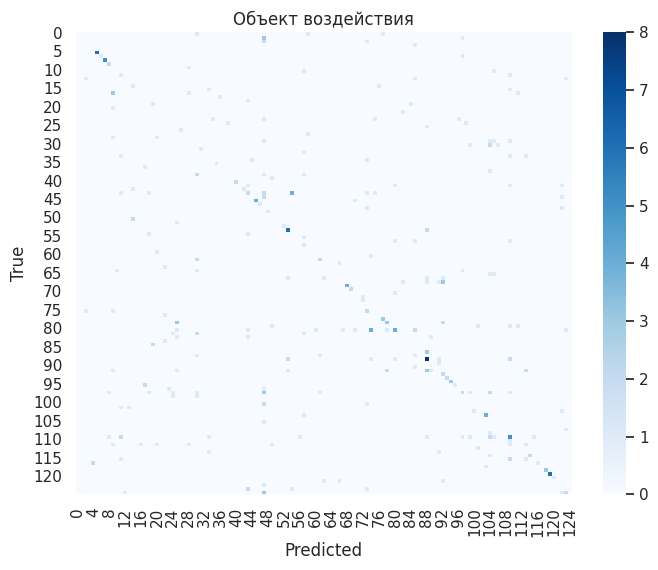

In [28]:
# 1. загрузили и очистили
df = change_dtype_dataframe(df)
df = basic_cleaning(df)
df = enrich_dataframe(df)

# 2. запускаем все модели
all_task_results = {}

for task_key, task_cfg in TASKS.items():
    print(f"\n{'=' * 80}")
    print(f"{task_key}: {task_cfg['task_name']}")
    print(f"{'=' * 80}")

    model = select_model_by_task(task_cfg["task_type"], model_name = "lgbm")

    result = run_experiment(
        df=df,
        task_name=task_cfg["task_name"],
        task_type=task_cfg["task_type"],
        target_col=task_cfg["target_col"],
        feature_cols=FEATURE_SETS["extended"],
        model=model,
        time_col="Региональное время",
        filter_fn=task_cfg["filter_fn"],
        test_size=0.2,
        n_splits=5,
        period=task_cfg["period"] if task_cfg["period"] is not None else 24
    )

    all_task_results[task_key] = result

    show_cv_results(result)

    if task_cfg["task_type"] in ["binary", "multiclass"]:
        plot_confusion(result)

    elif task_cfg["task_type"] in ["regression", "circular_regression"]:
        plot_regression_predictions(result)

In [29]:
summary_df = results_to_dataframe(
    {task_key: {"extended": result} for task_key, result in all_task_results.items()}
)

summary_df

,task_key,task_name,task_type,feature_set,n_rows,train_size,test_size,test_accuracy,test_balanced_accuracy,test_precision,...,cv_mean_circular_rmse,cv_mean_mae,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,cv_mean_f1_macro,cv_mean_f1_weighted,cv_mean_precision_macro,cv_mean_recall_macro
0,model_1_success,Успешность атаки,binary,extended,1770,1416,354,0.511299,0.514943,0.501976,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model_2_hour,Час наступления атаки,circular_regression,extended,891,712,179,NaN,NaN,NaN,...,0.398206,0.290555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,model_2_weekday,День недели атаки,multiclass,extended,891,712,179,1.000000,1.000000,NaN,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,model_2_season,Сезон атаки,multiclass,extended,891,712,179,1.000000,1.000000,NaN,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,0.806238,0.808200,0.793192,0.876132
4,model_3_threat_type,Тип угрозы,multiclass,extended,1770,1416,354,0.268362,0.255085,NaN,...,NaN,NaN,0.223641,0.268748,0.235859,0.228030,0.141051,0.183735,0.142786,0.159594
5,model_4_target_object,Объект воздействия,multiclass,extended,1770,1416,354,0.276836,0.258163,NaN,...,NaN,NaN,0.220980,0.273553,0.231680,0.235445,0.150289,0.202955,0.154636,0.171796


# Кластеризация 

In [45]:
df = init_data()

In [48]:
df.shape

(2000, 20)

In [49]:
df = change_dtype_dataframe(df)


In [51]:
df = basic_cleaning(df)

In [52]:
df.shape

(1770, 20)

In [53]:
df.columns

Index(['Тип предприятия', 'Код предприятия', 'Количество хостов',
       'Код реализованной угрозы', 'Успех', 'Регион размещения предприятия',
       'Дата инцидента', 'Региональное время', 'Идентификатор УБИ',
       'Наименование УБИ', 'Описание',
       'Источник угрозы (характеристика и потенциал нарушителя)',
       'Объект воздействия', 'Нарушение конфиденциальности',
       'Нарушение целостности', 'Нарушение доступности',
       'Дата включения угрозы в БнД УБИ', 'Дата последнего изменения данных',
       'Статус угрозы', 'Замечания'],
      dtype='str')

In [54]:
df = enrich_dataframe(df)

In [56]:
df.columns

Index(['Тип предприятия', 'Код предприятия', 'Количество хостов',
       'Код реализованной угрозы', 'Успех', 'Регион размещения предприятия',
       'Дата инцидента', 'Региональное время', 'Идентификатор УБИ',
       'Наименование УБИ', 'Описание',
       'Источник угрозы (характеристика и потенциал нарушителя)',
       'Объект воздействия', 'Нарушение конфиденциальности',
       'Нарушение целостности', 'Нарушение доступности',
       'Дата включения угрозы в БнД УБИ', 'Дата последнего изменения данных',
       'Статус угрозы', 'Замечания', 'Час_инцидента', 'День_недели', 'Месяц',
       'Квартал', 'Год', 'День_месяца', 'Выходной', 'Сезон', 'Час_sin',
       'Час_cos', 'ДеньНед_sin', 'ДеньНед_cos', 'Год_включения_угрозы',
       'Месяц_включения_угрозы', 'Дней_в_базе', 'Дней_с_включения_угрозы',
       'Размер инфраструктуры'],
      dtype='str')

In [ ]:
cat_cols = 

num_cols = 

text_cols = 

In [ ]:
models = ["catboost", "lgbm", "rf"]

In [ ]:
# 2. запускаем все модели
all_task_results = {}

for model in models:
    for task_key, task_cfg in TASKS.items():
        print(f"{task_key}: {task_cfg['task_name']}")

        model = select_model_by_task(task_cfg["task_type"], model_name = "lgbm")

        result = run_experiment(
            df=df,
            task_name=task_cfg["task_name"],
            task_type=task_cfg["task_type"],
            target_col=task_cfg["target_col"],
            feature_cols=FEATURE_SETS["extended"],
            model=model,
            time_col="Региональное время",
            filter_fn=task_cfg["filter_fn"],
            test_size=0.2,
            n_splits=5,
            period=task_cfg["period"] if task_cfg["period"] is not None else 24,
            cat_cols=cat_cols, 
            num_cols=num_cols, 
            text_cols=text_cols
        )

        all_task_results[task_key] = result

        show_cv_results(result)

        if task_cfg["task_type"] in ["binary", "multiclass"]:
            plot_confusion(result)

        elif task_cfg["task_type"] in ["regression", "circular_regression"]:
            plot_regression_predictions(result)

In [57]:
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [58]:
def means(f, X, n=0, start=2, end=15):

    silhouette_scores_kmeans = {}
    
    if n:
        start = n
        end = n
    
    for i in range(start, end+1):
        kmeans = f(n_clusters=i, random_state=42)

        prediction = kmeans.fit_predict(X)

        labels = kmeans.labels_
    
        score = silhouette_score(X, labels)

        silhouette_scores_kmeans[i] = score
        
    return prediction, score, silhouette_scores_kmeans

In [62]:
cat_cols = ['Описание','Источник угрозы (характеристика и потенциал нарушителя)', 'Объект воздействия']

In [77]:
X = df.copy()

In [79]:
preprocessor = build_preprocessor(X, cat_cols=cat_cols, num_cols=[], text_cols=[])

In [80]:
X = preprocessor.fit_transform(X)

In [82]:
from sklearn.metrics import silhouette_score

In [83]:
prediction, score, silhouette_scores_kmeans = means(KMeans, X)

In [84]:
best_kmeans_n = max(silhouette_scores_kmeans, key=silhouette_scores_kmeans.get)
best_kmeans_score = silhouette_scores_kmeans[best_kmeans_n]

In [88]:
best_algorithm = KMeans(n_clusters=best_kmeans_n, random_state=42)
best_labels = best_algorithm.fit_predict(X)

In [91]:
import plotly.express as px

Обработка perplexity = 5...


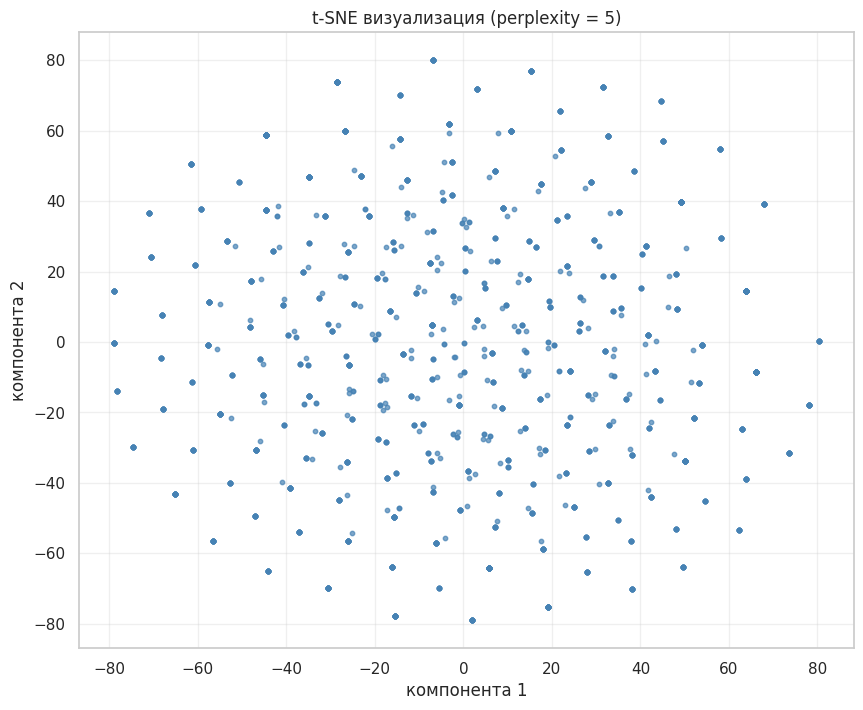

Обработка perplexity = 10...


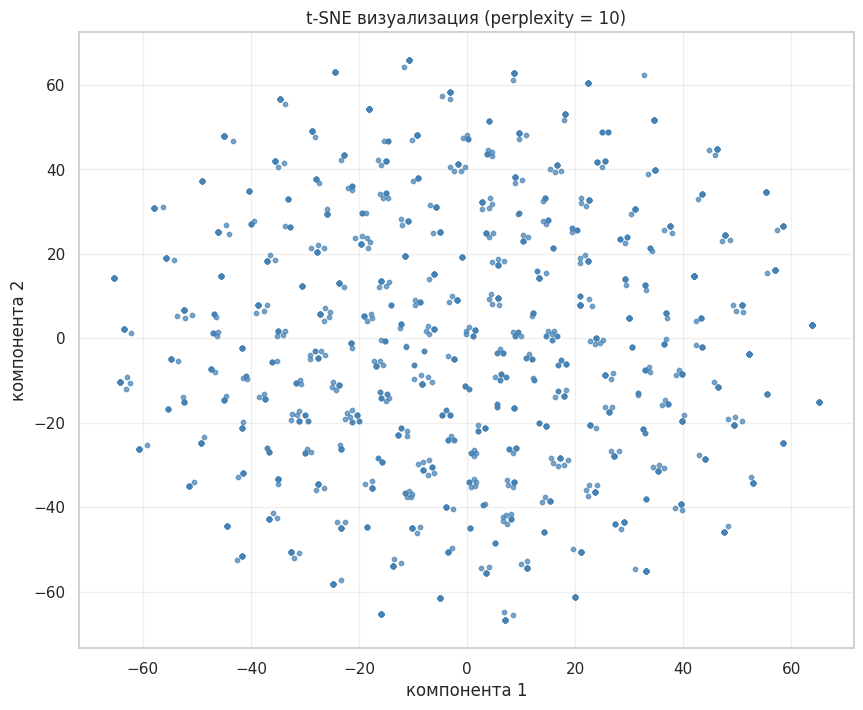

Обработка perplexity = 15...


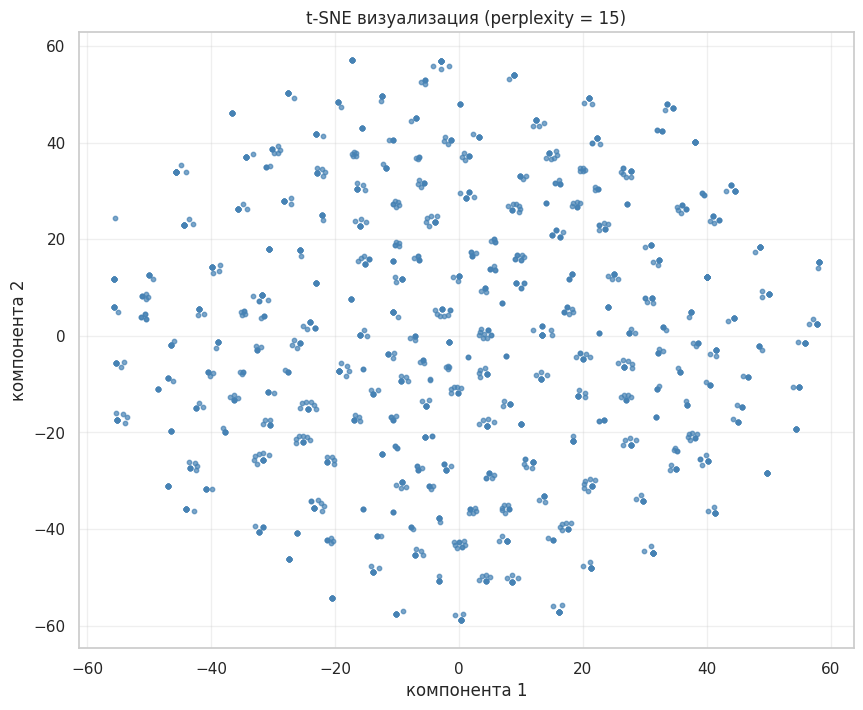

Обработка perplexity = 20...


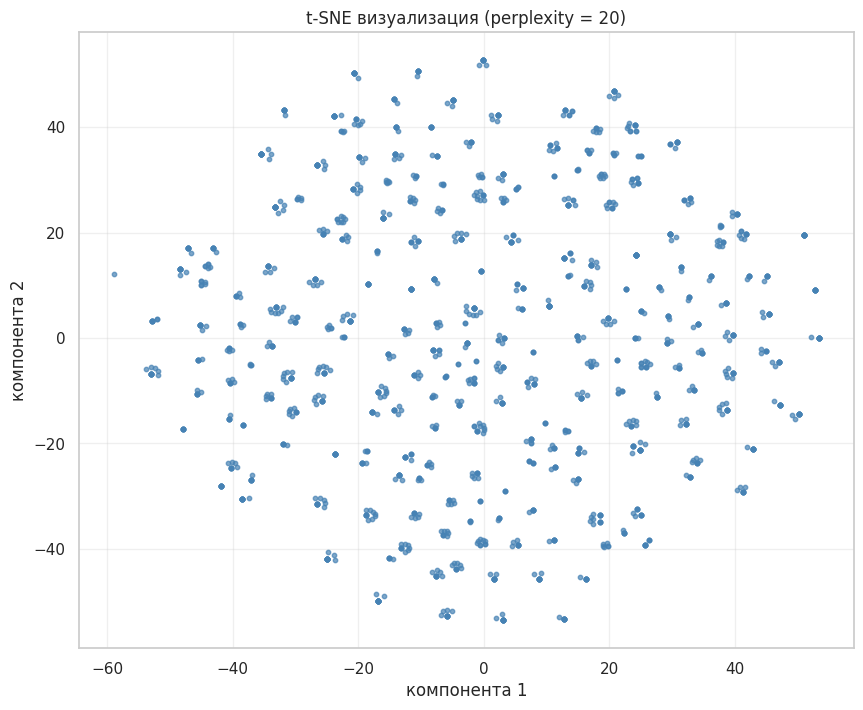

Обработка perplexity = 30...


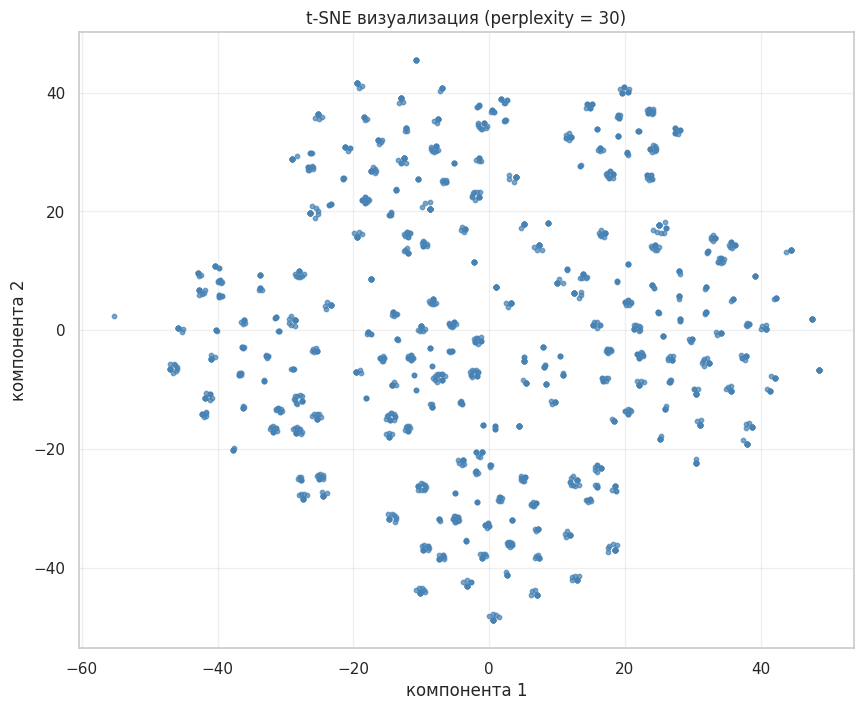

Обработка perplexity = 40...


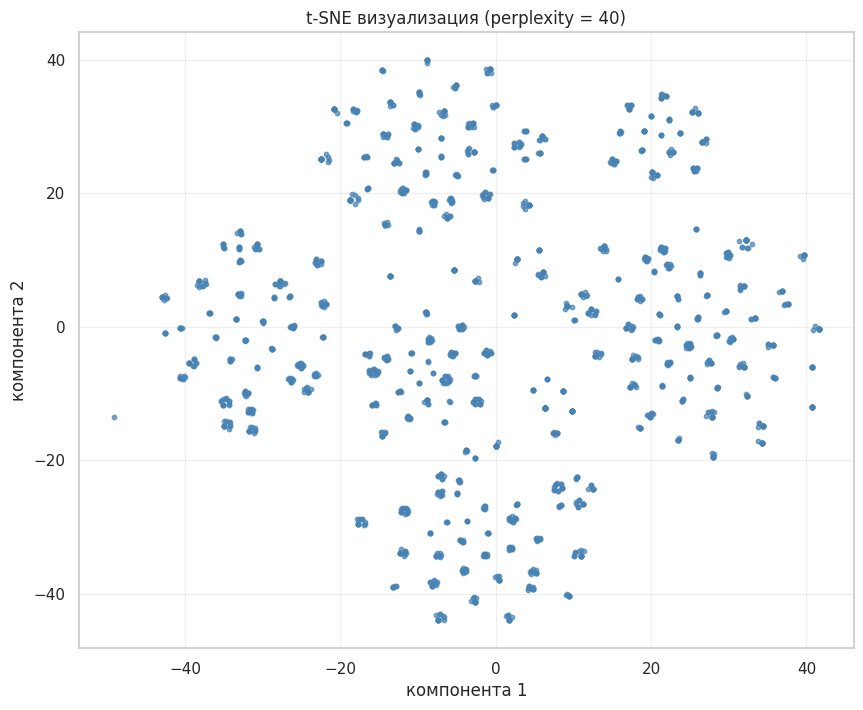

Обработка perplexity = 50...


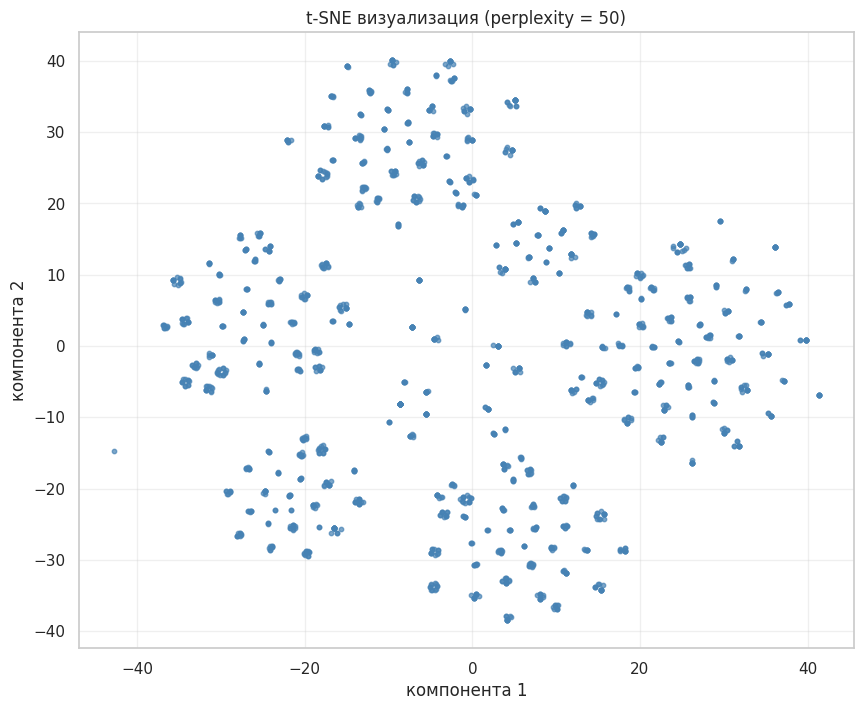

Обработка perplexity = 60...


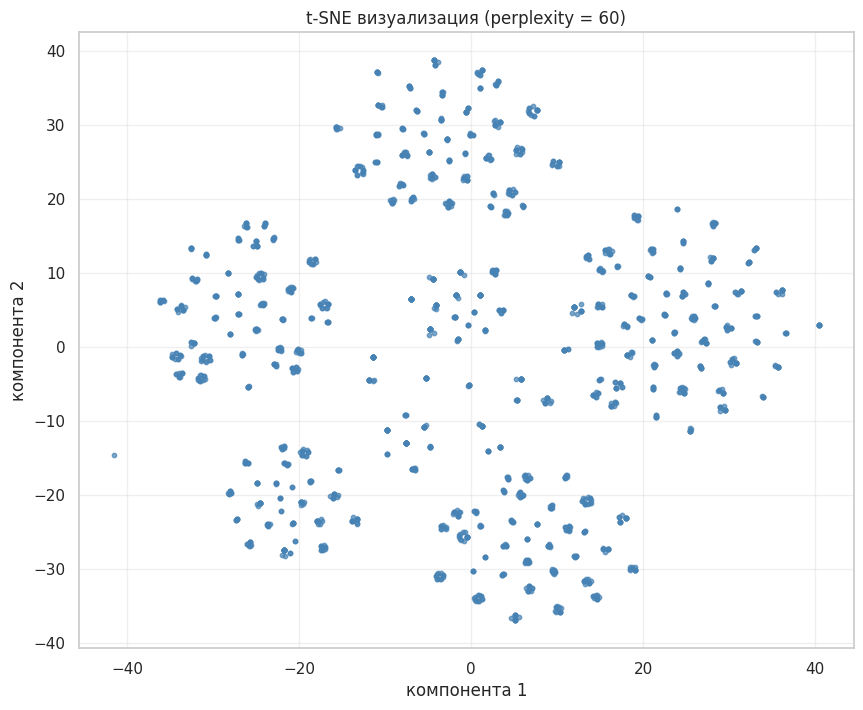

Обработка perplexity = 80...


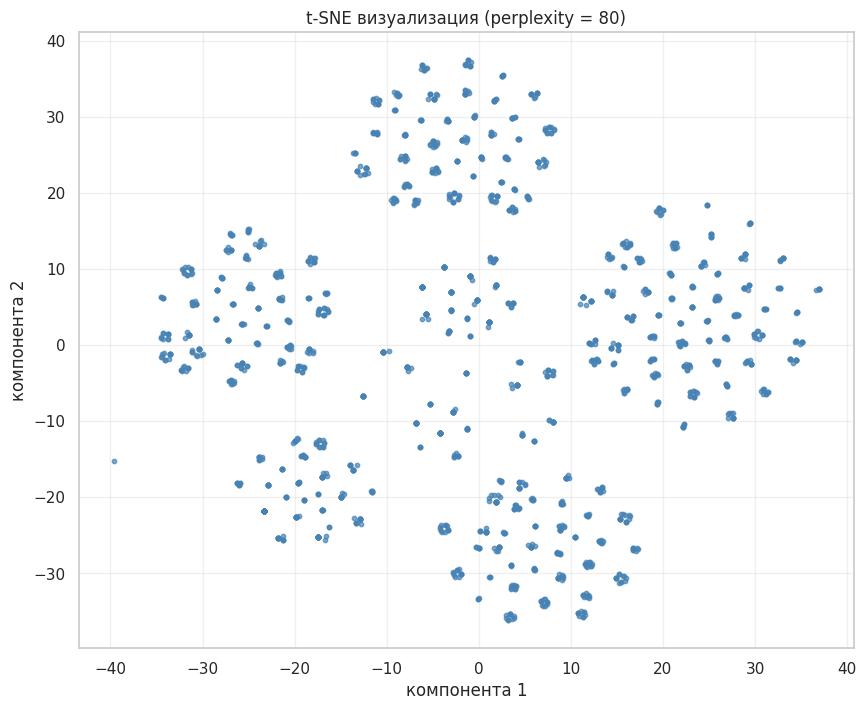

Обработка perplexity = 100...


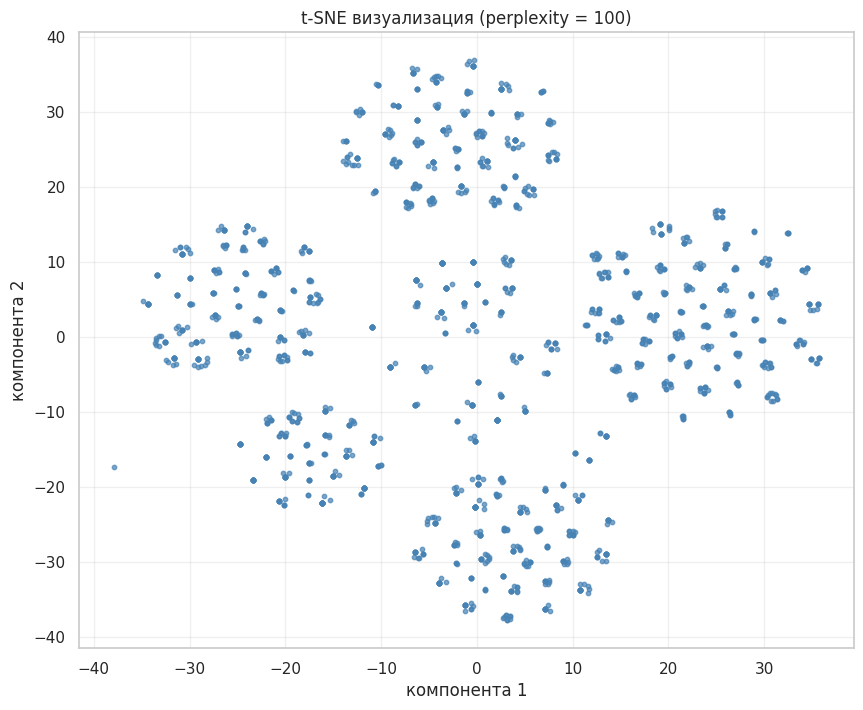

In [102]:
tsne_results = {}

for perp in [5, 10, 15, 20, 30, 40, 50, 60, 80, 100]:
    print(f"Обработка perplexity = {perp}...")
    
    tsne = TSNE(
        n_components=3-1, 
        perplexity=perp,
        n_jobs=4,
        random_state=42,
        max_iter=500,
        init='pca'
    )
    
    X_tsne = tsne.fit_transform(X)
    tsne_results[perp] = X_tsne
    
    plt.figure(figsize=(10, 8))
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.7, s=10, c='steelblue')
    plt.title(f't-SNE визуализация (perplexity = {perp})')
    plt.xlabel('компонента 1')
    plt.ylabel('компонента 2')
    plt.grid(True, alpha=0.3)
    plt.show()

In [97]:
best_perplexity = 100  

X_tsne_final = tsne_results[best_perplexity]

In [103]:
X_tsne_final

array([[-24.97782  ,   4.1191278],
       [ 15.900065 ,  -7.7705946],
       [-20.721544 ,   8.605968 ],
       ...,
       [ -4.691703 ,  18.509918 ],
       [-12.672836 ,  30.071114 ],
       [-22.274942 ,  13.0403185]], shape=(1770, 2), dtype=float32)

In [105]:
prediction, score, silhouette_scores_kmeans = means(KMeans, X)

In [106]:
df_full = df.copy()
df_full['cluster'] = prediction

In [107]:
df_full['cluster']

0       2
1       1
2       2
3       2
4       4
       ..
1765    4
1766    0
1767    4
1768    4
1769    5
Name: cluster, Length: 1770, dtype: int32

In [110]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 1770 entries, 0 to 1769
Data columns (total 38 columns):
 #   Column                                                   Non-Null Count  Dtype         
---  ------                                                   --------------  -----         
 0   Тип предприятия                                          1770 non-null   str           
 1   Код предприятия                                          1770 non-null   int64         
 2   Количество хостов                                        1770 non-null   int64         
 3   Код реализованной угрозы                                 1770 non-null   int64         
 4   Успех                                                    1770 non-null   int64         
 5   Регион размещения предприятия                            1770 non-null   str           
 6   Дата инцидента                                           1770 non-null   datetime64[us]
 7   Региональное время                                       1770 

In [ ]:
Тип предприятия         

Код зреалиованной угрозы                                 1770 non-null   int64         
Успех                                                    1770 non-null   int64         
Регион размещения предприятия                            1770 non-null   str           
 6   Дата инцидента                                           1770 non-null   datetime64[us]
 7   Региональное время                                       1770 non-null   datetime64[us]
 8   Идентификатор УБИ                                        1770 non-null   int64         
 9   Наименование УБИ                                         1770 non-null   str           
 10  Описание                                                 1770 non-null   str           
 11  Источник угрозы (характеристика и потенциал нарушителя)  1770 non-null   str           
 12  Объект воздействия                                       1770 non-null   str           
 13  Нарушение конфиденциальности                             1770 non-null   int64         
 14  Нарушение целостности                                    1770 non-null   int64         
 15  Нарушение доступности                                    1770 non-null   int64         
 16  Дата включения угрозы в БнД УБИ                          1770 non-null   datetime64[us]
 17  Дата последнего изменения данных                         1770 non-null   datetime64[us]
 18  Статус угрозы                                            1770 non-null   str           
 19  Замечания                                                0 non-null      str           
 20  Час_инцидента                                            1770 non-null   int32         
 21  День_недели                                              1770 non-null   int32         
 22  Месяц                                                    1770 non-null   int32         
 23  Квартал                                                  1770 non-null   int32         
 24  Год                                                      1770 non-null   int32         
 25  День_месяца                                              1770 non-null   int32         
 26  Выходной                                                 1770 non-null   int64         
 27  Сезон                                                    1770 non-null   int64         
 28  Час_sin                                                  1770 non-null   float64       
 29  Час_cos                                                  1770 non-null   float64       
 30  ДеньНед_sin                                              1770 non-null   float64       
 31  ДеньНед_cos                                              1770 non-null   float64       
 32  Год_включения_угрозы                                     1770 non-null   int32         
 33  Месяц_включения_угрозы                                   1770 non-null   int32         
 34  Дней_в_базе                                              1770 non-null   int64         
 35  Дней_с_включения_угрозы                                  1770 non-null   int64         
 36  Размер инфраструктуры                                    1770 non-null   category      
 37  cluster                                                  1770 non-null   int32         

In [ ]:
ALL_FEATURES_EXCLUDE = [
    "Успех",
    "Код реализованной угрозы",
    "Объект воздействия",
    "Региональное время",
    "Дата инцидента"
]

base_features = [
    "Количество хостов",
    "Источник угрозы (характеристика и потенциал нарушителя)",
    "Размер инфраструктуры",
    "Дней_в_базе",
    "Год_включения_угрозы",
    "Месяц_включения_угрозы"
]

time_features = [
    "Час_sin", "Час_cos",
    "ДеньНед_sin", "ДеньНед_cos",
    "Месяц", "Квартал", "Выходной"
]

In [ ]:
cat_cols=cat_cols, 
num_cols=[
    "Час_sin", "Час_cos",
    "ДеньНед_sin", "ДеньНед_cos",
    "Месяц", "Квартал", "Выходной"
] 
text_cols=text_cols

In [ ]:
# 2. запускаем все модели
all_task_results = {}

for model in models:
    for task_key, task_cfg in TASKS.items():
        print(f"{task_key}: {task_cfg['task_name']}")

        model = select_model_by_task(task_cfg["task_type"], model_name = "lgbm")

        result = run_experiment(
            df=df,
            task_name=task_cfg["task_name"],
            task_type=task_cfg["task_type"],
            target_col=task_cfg["target_col"],
            feature_cols=FEATURE_SETS["extended"],
            model=model,
            time_col="Региональное время",
            filter_fn=task_cfg["filter_fn"],
            test_size=0.2,
            n_splits=5,
            period=task_cfg["period"] if task_cfg["period"] is not None else 24,
            cat_cols=cat_cols, 
            num_cols=num_cols, 
            text_cols=text_cols
        )

        all_task_results[task_key] = result

        show_cv_results(result)

        if task_cfg["task_type"] in ["binary", "multiclass"]:
            plot_confusion(result)

        elif task_cfg["task_type"] in ["regression", "circular_regression"]:
            plot_regression_predictions(result)